**1.1 Methodology:**

**Box-Least-Squares (BLS) Period Search**

To detect periodic dips in the photometric light curve, we implement a custom Box-Least-Squares (BLS) algorithm from first principles. 

**Phase-Folding & Weighted Binning**

For each trial period $P$, data timestamps $t_i$ are phase-folded according to:$$\phi_i = t_i \pmod P, \quad 0 \le \phi_i < P$$Data points are weighted by their inverse variance, $w_i = 1 / \sigma_i^2$, yielding a weighted mean baseline flux:$$\hat{f} = \frac{\sum_i f_i w_i}{\sum_i w_i}, \quad T = \sum_i w_i$$Subtracting this baseline produces mean-subtracted fluxes $\tilde{f}_i = f_i - \hat{f}$. The folded phase curve is partitioned into uniform phase bins with widths matched to typical transit durations ($\sim 3$ hours for hot Jupiters):$$\Delta \phi = \frac{3}{24} \text{ days} = 0.125 \text{ days}, \quad N_{\text{bins}} = \left\lfloor \frac{P}{\Delta \phi} \right\rfloor$$

**Detection Statistics**

For each phase bin $j$, we compute the weighted flux sum $S_j$ and weight sum $R_j$:$$S_j = \sum_{i \in \text{bin } j} \tilde{f}_i w_i, \quad R_j = \sum_{i \in \text{bin } j} w_i$$The transit depth $\delta_j$ and the detection significance metric $\Delta\chi^2_j$ are evaluated as:$$\delta_j = \frac{-S_j T}{R_j (T - R_j)}, \quad \Delta\chi^2_j = \frac{S_j^2 T}{R_j (T - R_j)}$$For each trial period across the grid $P \in [1.0, 10.0]$ days ($\Delta P = 0.01$ days), the maximum $\Delta\chi^2_j$ identifies the optimal bin, mid-transit epoch $t_0$, and candidate transit depth.

In [10]:
# Importing modules
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [14, 8]

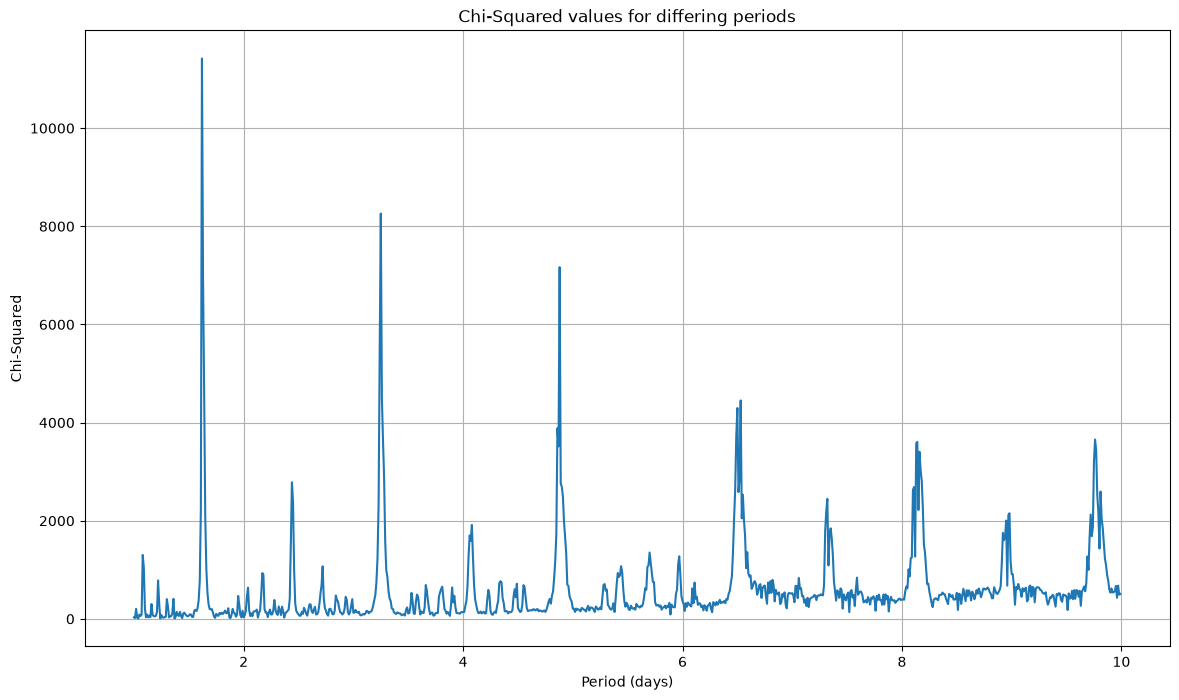

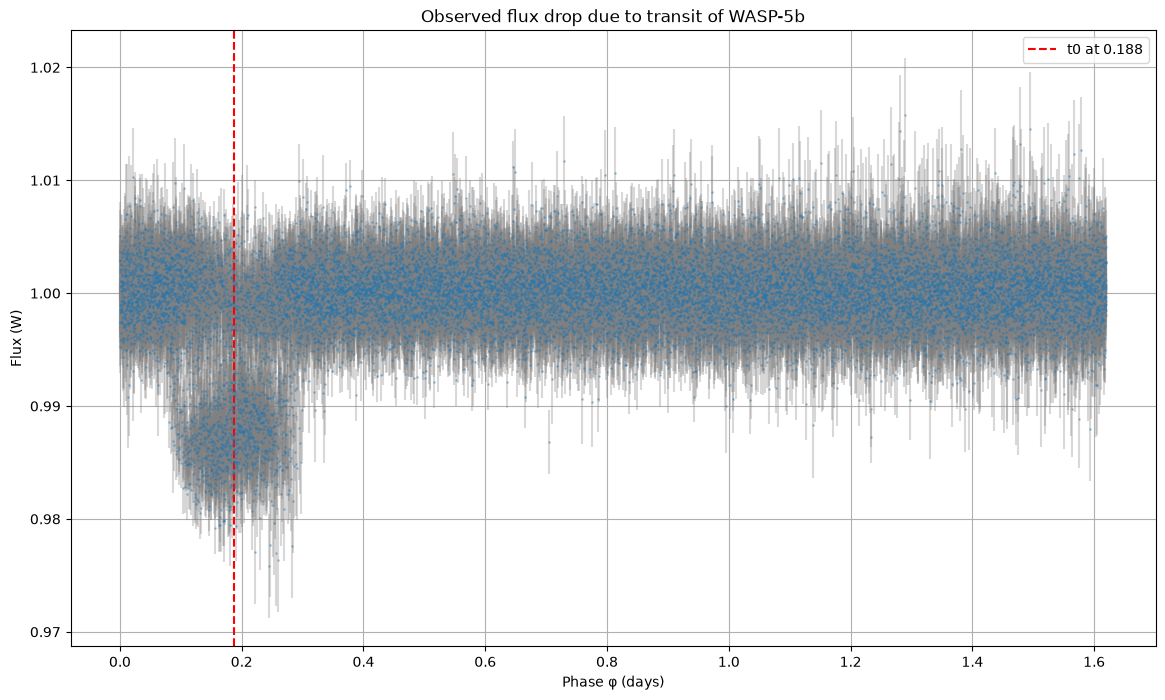

The best fit period was found to be 1.620 days
The associated depth is 0.007 (flux drop in W)
The epoch is 2088.432 days


In [11]:

def transit_finding_func(time, flux, flux_err):
    #stats
    weight = 1/(flux_err**2)
    mean_flux = np.sum(flux * weight) / np.sum(weight)
    flux_tilda = flux - mean_flux
    T = np.sum(weight)
    
    period_vals = []
    chi_sq_vals = []
    depth_vals = []
    t0_vals = []
    for period in np.arange(1.0, 10.0, 0.01):
        period_vals.append(period)
        phi = time % period
        #bin calculations
        bin_width = 3/24
        num_bins = int(period / bin_width)
        S = np.zeros(num_bins)
        R = np.zeros(num_bins)
        bin_indices = (phi / bin_width).astype(int)
        for a in range(num_bins): #only iterates over each bin
            mask = (bin_indices == a) # this mask selects all data points from a certain bin
            if np.any(mask):
                S[a] = np.sum(flux_tilda[mask] * weight[mask]) # covers aLL points in the bin due to them being encompassed in the mask
                R[a] = np.sum(weight[mask])

        depth_bins = np.zeros(num_bins)
        chi_sq_bins = np.zeros(num_bins)
        for a in range(num_bins):
            if 0 < R[a] < T: #safety check in case bin is empty and demonimator = 0
                denom = R[a] * (T - R[a])
                depth_bins[a] = (-S[a] * T) / denom
                chi_sq_bins[a] = (S[a]**2 * T) / denom

        chi_sq_max = np.max(chi_sq_bins)
        chi_sq_vals.append(chi_sq_max) # adds to array of total best chi sq vals with varying period trial vals
        best_bin = np.argmax(chi_sq_bins) # bin where dip is most likely to be, has max chi sq 
        depth_vals.append(depth_bins[best_bin]) # depth value is going to be from best bin - one where depth is expected to be

        #epoch (t0) calculations
        min_time = np.min(time)
        bin_centre_phase = (best_bin + 0.5) * bin_width # plus 0.5 gives middle of bin
        t0 = np.min(time) + bin_centre_phase
        t0_vals.append(t0)

    return period_vals, chi_sq_vals, depth_vals, t0_vals 

time, flux, flux_err = np.loadtxt('wasp-5b.txt', unpack=True)
periods, chi_sqs, depths, t0s = transit_finding_func(time, flux, flux_err)
plt.plot(periods, chi_sqs)
plt.title('Chi-Squared values for differing periods')
plt.ylabel('Chi-Squared')
plt.xlabel('Period (days)')
plt.grid(True)
plt.savefig('periodogram.png', dpi=300, bbox_inches='tight')
plt.show()

chi_sq_max_pointer = np.argmax(chi_sqs)
best_period = periods[chi_sq_max_pointer]
best_depth = depths[chi_sq_max_pointer]
best_t0 = t0s[chi_sq_max_pointer]
phi = time % best_period
best_phase = (best_t0 - np.min(time)) % best_period

plt.errorbar(phi, flux, yerr=flux_err, fmt='o', markersize=1, ecolor='gray', alpha=0.3)
plt.axvline(best_phase, color='red', linestyle='--', label=f't0 at {best_phase:.3f}')
plt.title('Observed flux drop due to transit of WASP-5b')
plt.ylabel('Flux (W)')
plt.xlabel('Phase φ (days)')
plt.grid(True)
plt.legend()
plt.savefig('fluxdrop.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'The best fit period was found to be {best_period:.3f} days')
print(f'The associated depth is {best_depth:.3f} (flux drop in W)')
print(f'The epoch is {best_t0:.3f} days')



**2.1 Methodology:** 

**Analytic Transit Inversion & Parameter Extraction**

Following candidate period detection, we refine the system parameters—orbital period $P$, mid-transit epoch $t_0$, normalized semi-major axis $a/R_*$, and planet-to-star radius ratio $p = R_p/R_*$—by fitting an analytic occultation model to the full TESS light curve.  


**Geometric Transit Model**

Assuming a spherical exoplanet occulting a uniform-brightness stellar disc of unit radius ($R_* = 1$), the unobscured flux is given by:$$F(p, z) = 1 - \lambda(p, z)$$where $z = d / R_*$ is the projected centre-to-centre separation of the bodies in units of stellar radii, evaluated from the orbital phase angle $\theta(t) = 2\pi(t - t_0) / P$ as $d = \vert{}a \sin\theta\vert{}$.  The obscured flux fraction $\lambda(p, z)$ across occultation regimes is defined as:$$\lambda(p, z) = \begin{cases}  0, & 1 + p < z \quad \text{or} \quad \cos\theta < 0 \quad \text{(out of transit / occultation behind star)} \\  p^2, & z \le 1 - p \quad \text{(full transit)} \\  \frac{1}{\pi} \left[ p^2 \kappa_0 + \kappa_1 - \sqrt{\frac{4z^2 - (1 + z^2 - p^2)^2}{4}} \right], & \vert{}1 - p\vert{} < z \le 1 + p \quad \text{(ingress / egress)} \end{cases}$$where the arc angles $\kappa_0$ and $\kappa_1$ represent:$$\kappa_0 = \cos^{-1}\left( \frac{p^2 + z^2 - 1}{2pz} \right), \quad \kappa_1 = \cos^{-1}\left( \frac{1 - p^2 + z^2}{2z} \right)$$

**Non-Linear Optimization & Parameter Estimation**

Using initial estimates derived from the BLS periodogram ($P_0$, $t_{0}$, and $p_0 \approx \sqrt{\delta}$), the non-linear curve is optimized via Levenberg-Marquardt least-squares fitting using scipy.optimize.curve_fit.  Physical planetary parameters are subsequently converted into SI and astronomical units using known host star properties ($R_* = 1.08\,R_{\odot}$):  Exoplanet Radius ($R_p$): $R_p = p \cdot R_*$  Orbital Semi-Major Axis ($a$): Converted from stellar radii to Astronomical Units ($1\,\text{AU} = 215.032\,R_{\odot}$)  

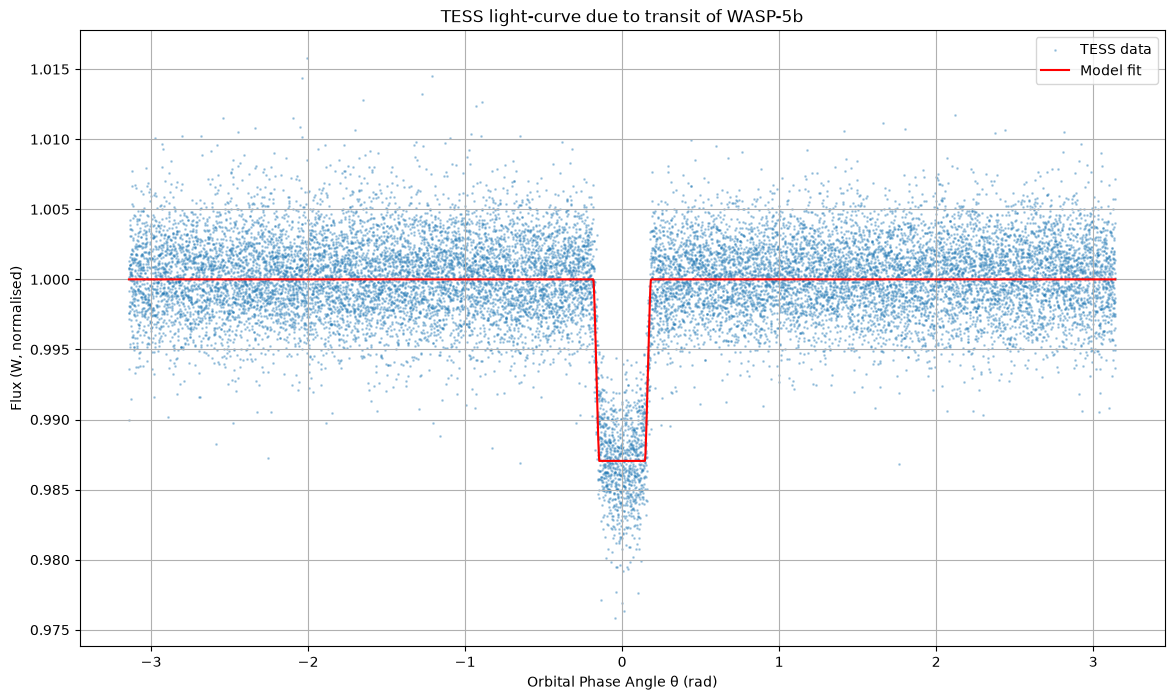

Refined orbital period: 1.628432 days
Refined epoch t0: 2088.301651 days
Radius of planet: 8.550e+07 m
Radius planet in terms of Jupiter radii: 1.195986 R_Jupiter
Orbital radius of the planet: 0.030671 AU


In [12]:

#initial constants needed for function
p = np.sqrt(best_depth) # initial guess for size ratio
a0 = 5 #initial guess of a

def lightcurve_model(time, period, t0, a, p):
    theta = 2*np.pi*(time - t0)/period # orbital phase angle array
    d = np.abs(a*np.sin(theta)) #centre - centre distacne from star to planet
    z = d #simplification that Rstar = 1
    num_points = len(time)
    wavelength = np.zeros(num_points)
    for i in range(num_points):
        if (1 + p) < z[i] or np.cos(theta[i]) <0:
            wavelength[i] = 0
        elif (np.abs(1-p) < z[i] < (1+p)):
            k0 = np.arccos((p**2 + z[i]**2 -1)/(2*p*z[i]))
            k1 = np.arccos((1- p**2 + z[i]**2)/(2*z[i])) #k0 and k1 only defined when the planet is overlapping star
            wavelength[i] = ((1/np.pi) * ((p**2)*k0 + k1 - np.sqrt((4*z[i]**2 - (1+z[i]**2 - p**2)**2) / 4)))
        elif z[i] <= (1-p):
            wavelength[i] = p**2

    F = 1-wavelength #flux formula given
    return F

initial_params = [best_period, best_t0, a0, np.sqrt(best_depth)]
popt, pcov = curve_fit(lightcurve_model, time, flux, p0=initial_params) #using curve fit fuction to find ideal params
final_period, final_t0, final_a, final_p = popt #unpacking params
theta_values = 2*np.pi*(time - final_t0) / final_period #had to calculate final theta values outside defined function due to curve fit
theta_folded = (theta_values + np.pi) % (2 * np.pi) - np.pi #theta values folded onto each other (sincee transit is periodic)
F_values = lightcurve_model(time, final_period, final_t0, final_a, final_p)
sorted_points = np.argsort(theta_folded) #sorts the points from smallest to largest for the fit
plt.scatter(theta_folded, flux, s=1, alpha=0.3, label='TESS data') #original noisy data 
plt.plot(theta_folded[sorted_points], F_values[sorted_points], color='red', label='Model fit') #fitted plot with normalised flux
plt.title('TESS light-curve due to transit of WASP-5b')
plt.xlabel('Orbital Phase Angle θ (rad)')
plt.ylabel('Flux (W, normalised)')
plt.legend()
plt.grid(True)
plt.savefig('transit_fit.png', dpi=300, bbox_inches='tight')
plt.show()

R_sun = 695700000 #m
R_star = 1.08 * R_sun
R_jup = 0.102763 * R_sun
R_planet = final_p * R_star
# a in in units of R_star
R_orbit = (final_a * 1.08)/ 215.032 #in Au now

print(f'Refined orbital period: {final_period:.6f} days')
print(f'Refined epoch t0: {final_t0:.6f} days')
print(f'Radius of planet: {R_planet:.3e} m')
print(f'Radius planet in terms of Jupiter radii: {R_planet / R_jup:.6f} R_Jupiter')
print(f'Orbital radius of the planet: {R_orbit:.6f} AU')

### 3. Summary of Inferred System Properties

By combining first-principles BLS detection with analytic non-linear occultation modeling, we estimated the physical parameters of the WASP-5b system:

| Parameter | Inferred Value | Physical Units |
| :--- | :--- | :--- |
| **Orbital Period ($P$)** | **1.628432** | days |
| **Mid-Transit Epoch ($t_0$)** | **2088.301651** | days |
| **Planetary Radius ($R_p$)** | **$8.550 \times 10^7$** | m |
| **Planetary Radius ($R_{\text{Jup}}$)** | **1.196** | $R_{\text{Jupiter}}$ |
| **Semi-Major Axis ($a$)** | **0.030671** | AU |

The derived values are closely aligned with published literature ($P \approx 1.6284$ days, $R_p \approx 1.17\text{--}1.25 \, R_{\text{Jup}}$), confirming the sub-stellar nature of the transiting Hot Jupiter companion.